# Week 5 - Bivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [16]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

# 1. Lesson: Bivariate graphs

In this lesson, we'll consider some bivariate plots: scatter plots, line plots, waterfall plots, area plots, and pair plots.  We'll also look at bivariate statistics such as correlations, ratios, and percentages.  First, let's create some data.

In [17]:
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)

This scatter plot puts one series against another.  The two series are anticorrelated - one goes up when the other goes down.

<Axes: >

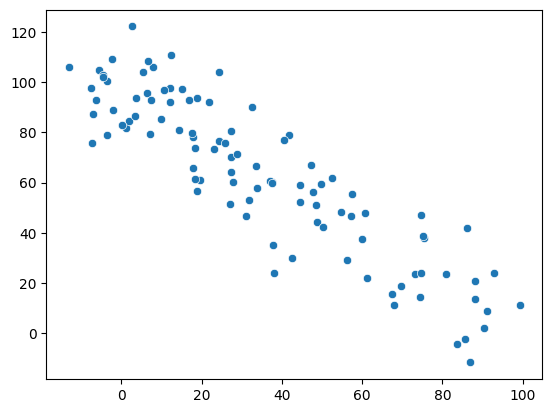

In [18]:
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse)

This pair plot compares three series against one another.  The diagonal shows the histogram of each series, while the non-diagonal entries plot two different series against each other.  The result in column 1, row 2 is a scatter plot that compares series #1 with series #2.  In effect, when the logic of the pair plot tells us to plot a series against itself (column 1, row 1), we draw a histogram.  (It would be silly to draw a scatter plot of a series against itself).  Because series #1 is not based on the "base" series, it is not correlated with series #2 or series #3, so the four scatter plots that compare series #1 to #2 and #3 look patternless.  The two scatter plots that compare series #2 with series #3 do appear to be correlated due to the "base" series that they share in common.

In [19]:
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])

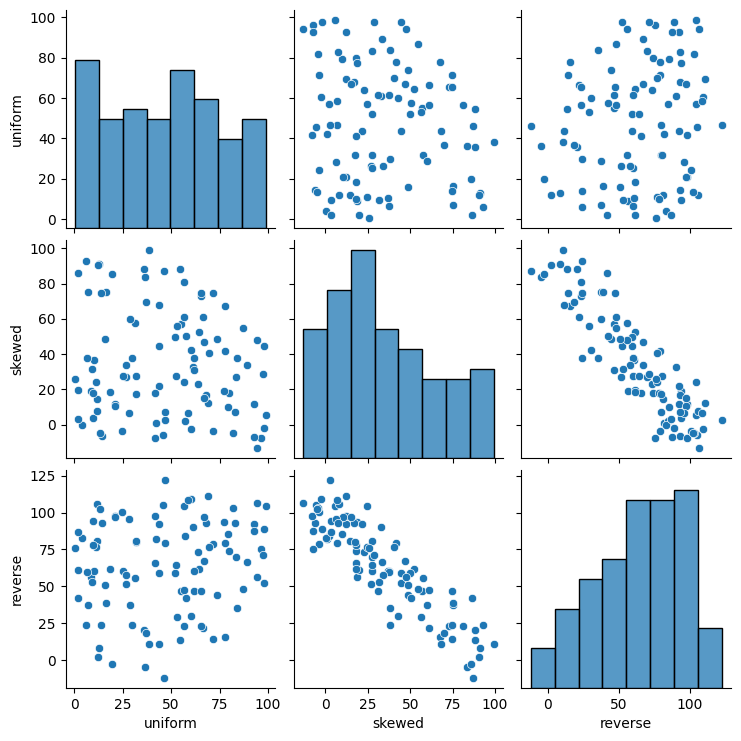

In [20]:
sns.pairplot(df)

We can compute the correlation coefficience between each pair.

In [21]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


This shows that there is a strong negative correlation between the "skewed" and "reverse" datasets (a larger negative number in row 2, column 3 and in row 3, column 2) and almost no correlation between the "uniform" dataset and the others (the much smaller numbers at those locations in the table.)

Q: What is a correlation telling us?

If the correlation is large (close to 1) it tells us that the two variables are usually either both large or both small in value.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the lower left to upper right.

If the correlation is very negative (close to -1), it tells us that when one variable is large, the other is small.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the upper left to lower right.

If the correlation is zero, it tells us that the two variables, plotted on a scatter plot, would form a cloud.  The cloud can have different shape - for instance, it could be square or circular - but it cannot look like a diagonal line.  Knowing the value of one variable would tell you nothing about the value of the other variable.  (At least, it would not tell you whether the other variable is large or small).

The correlation coefficients above are called by the letter R.  R can be positive or negative, and lies between -1 and 1.  If we square R, we get a value called $R^2$ which is sometimes used to describe the correlation.  Unless R = 0 or 1, $R^2$ will be smaller in magnitude than R (and always positive), which means that it is very important to know if you are talking about R or $R^2$.  Since the values above can be negative, you can know for sure that they are R values, not $R^2$.

Q: How do you decide if a correlation is strong?

It depends on the application.  Some sources say that a correlation of R = 0.7 or 0.8 is strong, but in other applications (say, the social sciences) a correlation of 0.5 might be considered quite strong.  It is not unusual for social scientists to report correlations even as low a 0.2 as being important.

Q: What is the purpose of finding a correlation?

Here are a few:

1. Variables that are correlated with a target variable might be especially useful in predicting that variable.  This might also suggest that a linear model could work.  On the other hand, just because there are no pairwise correlations doesn't mean that a linear model won't work.  For example, if you select X, Y, and Z from this list of four possibilities: \[\[X = 1, Y = 0, Z = 0], \[X = 0, Y = 1, Z = 0], \[X = 0, Y = 0, Z = 1], \[X = 1, Y = 1, Z = 1]] then any two variables are completely uncorrelated, but the sum of the three is usually 1.  So the linear model Z = 1 - X - Y is accurate in three out of four cases even though all pairwise correlations are zero.

2. Variables that are very correlated with each other might be redundant.  In the extreme case, two variables that have a correlation of 1.0 are "linearly dependent" - they essentially provide the same information.  For example, if one column is a height in inches, and another is a height in centimeters, then they are redundant.  Moreover, if you use two highly correlated variables as predictors, the results will be somewhat unpredictable.  For example, if HI is the height in inches and HC is the height in centimeters, then the following formulas are all equivalent: HC, 2.54 * HI, 0.5 * HC + 1.27 * HI, 1001 * HC - 2540 * HI.  So there's no knowing which one you'll get if you try to build a model based on these variables.  The last one in particular is a little bit surprising, given the large coefficients, but it could very well be the result of a linear regression analysis.

3. Correlation can help you to detect problems with the data.  If two variables are correlated but shouldn't be, or if they're not correlated but should be, there might be something wrong with the data.  It's important to test the data to see if it makes sense.

4. Correlations can be interesting things to report.  If your client or organization is asking for a verbal explanation of the dataset, they might be interested in knowing about any correlations for reasons of their own.

A waterfall chart shows a value after a sequence of inputs and outputs.

In [22]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name='This title is not displayed',
    orientation='v',
    measure=['absolute','relative','relative','relative','relative'],
    x=["2023-Jan", "receipts-in", "interest-in", "expenses-out", "interest-out", "2024-Jan"],
    textposition='outside',
    text=['Total','after-receipts','after-interest','after-expenses','after-interest'],
    y=[123.45,42.08,21.97,-54.31,-50.23],
    connector=dict(line=dict(color='rgb(63, 63, 63)'))
))

fig.update_layout(
    title='Waterfall Plot',
    showlegend=False
)
fig.update_yaxes(range=[-1,230])
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

A line plot is typically associated with a time or date range.  It shows how a variable rises and falls over a period of time.

In [ ]:
numdates = 12
time_series = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
sns.lineplot(x = datearray, y = time_series)

An area plot stacks one curve on top of another.  In the graph below, the top line shows the sum of the two series (ser1 + ser2) while the bottom line just shows ser1.

In [ ]:
time_series_2 = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 2. Weekly graph question

Below is a pair plot showing the correlation between the levels of chemical A, B, and C in a water sample.  If you had to choose just _three_ of the nine graphs in the pair plot to display, which would you choose?  How would you alter the way these graphs are displayed to make them clearer or more informative?  Would you fit any of these graphs to a line or curve?  Why or why not?  What if you had to choose just _one_?  What if you had to choose _six_?

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)
num_data = 100
base_data = np.random.random(size = num_data)
chem1 = base_data + np.random.normal(size = num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size = num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size = num_data) * 0.1
df_chem = pd.DataFrame({'chem1':chem1,'chem2':chem2,'chem3':chem3})

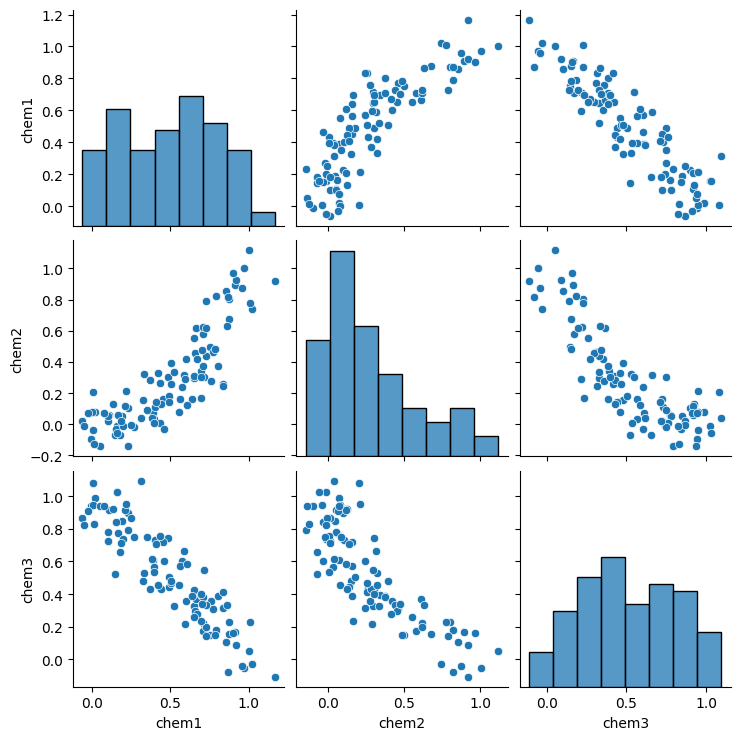

In [ ]:
sns.pairplot(df_chem)

### Choose Just Three Graphs
If I had to choose just three of these plots, I would choose:
* A scatter plot comparing Chem 1 and Chem 2
* A scatter plot comparing Chem 1 and Chem 3
* A scatter plot comparing Chem 2 and Chem 3

This would give me a thorough visual of how all the chemicals relate to one another. 

### How Would I Alter These Graphs
* I would ensure all the axises use the same range to ensure clearer understanding and comparison.
* I would take the graphs out of the matrix and look at them one by one to better compare them.
* I would ensure all the graphs had a title.


### Would I fit these Graphs to a Line
* I would definetly fit these graphs to a line. They display correlation between two variables and all the scatter plots show a strong linear correlation, based on the way they either increase together or inversely increase and decrease. Therefore, these graphs would all be great to visualize against a line.

### Choose Just One Graph
* If I had to choose just one graph, I would select the scatter plot comparing Chem 1 and Chem 2. This is because Chem 1 and Chem 2 is the only relationship with positive correlation. The relationship between Chem 1 and Chem 3 and Chem 2 and Chem 3 are both very similarly inversely correlated. Therefore, if I could only look at 1, I would look at the one relationship that is fully unique.

### Choose Six Graphs
* If I had to choose six graphs, I would choose three graphs of the relationships between each unique combination of chemicals:
    * Chem 1 and Chem 2
    * Chem 1 and Chem 3
    * Chem 2 and Chem 3
* I would also choose the histograms of each chemical against itself.
* The reasoning for this is that these graphs are displayed as a matrix, so there are duplicate graphs being shwown. For example, the correlation between Chem 1 and Chem 2 can be seen two different times within the matrix, and I don't think it's beneficial to show the audience the same correlation twice within the same visual, this may be confusing for the audience.

# 3. Homework - Reproducing Pair Plot Graphs

I'm going to show you some Pair Plot (Scatter and Histogram) graphs.  I'd like you to generate some data that will generate those graphs.

Example: this cloud involves a match between two normal distributions.

<Axes: xlabel='data1', ylabel='data2'>

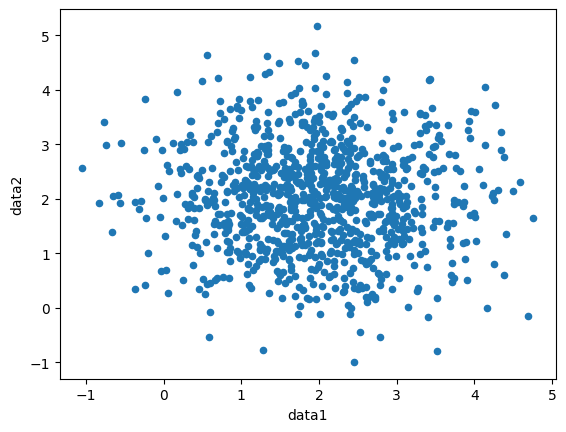

In [ ]:
num_points = 1000
np.random.seed(0)
data1 = np.random.normal(size = num_points) + 2
data2 = np.random.normal(size = num_points) + 2
df_twonorm = pd.DataFrame({"data1":data1,"data2":data2})
df_twonorm.plot.scatter(x = "data1", y = "data2")

Problem: Can you design data that will generate the following scatter plot?  You may need to join multiple series to make one big series for the y-axis data.  That will allow you to create the two clouds. Use Google or ChatGPT to find the function that does that.  It is okay if the precise numbers are not re-created; just the general shape: two vertically separated clouds of points.

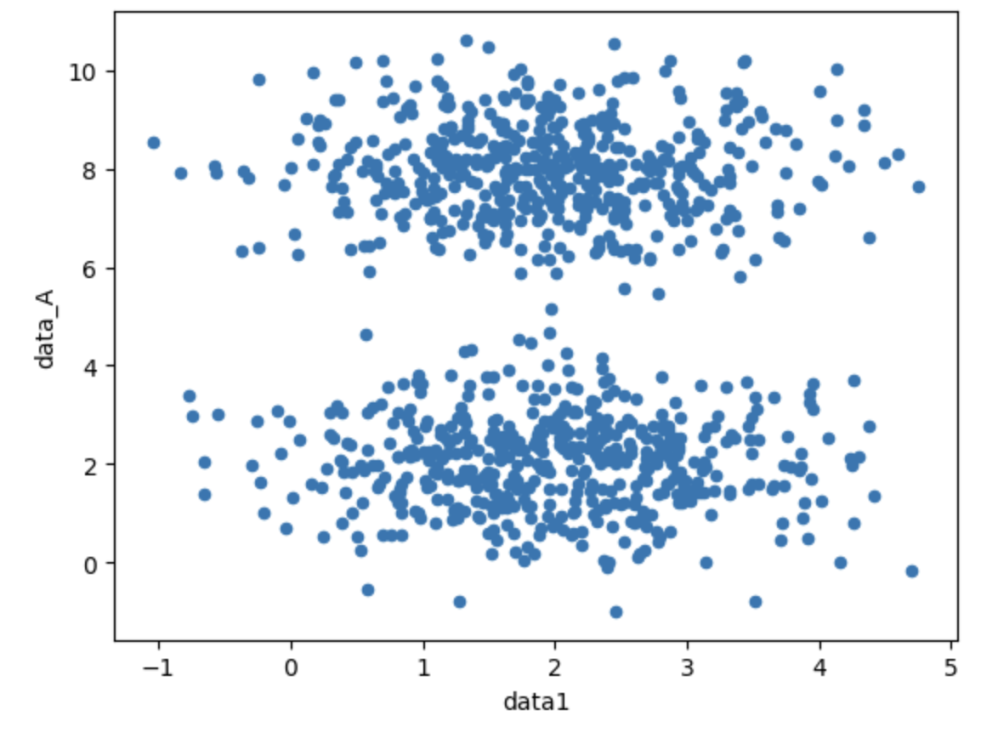

In [23]:
from IPython.display import Image
Image("images/twoclouds.webp")

In [26]:
import matplotlib.pyplot as plt

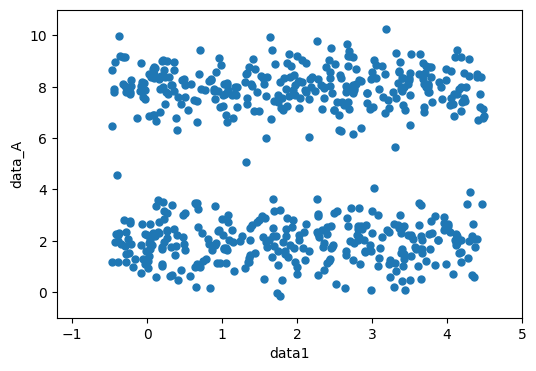

In [ ]:
# Reproducibility
rng = np.random.default_rng(42)

# How many points in each cloud
n = 300

# X spread (roughly like your figure)
x1 = rng.uniform(-0.5, 4.5, size=n)
x2 = rng.uniform(-0.5, 4.5, size=n)

# Two vertical bands (clouds)
y1 = rng.normal(loc=2.0, scale=0.8, size=n)   # lower cloud
y2 = rng.normal(loc=8.0, scale=0.8, size=n)   # upper cloud

# **Join multiple series** to make one big series
x = np.concatenate([x1, x2])
y = np.concatenate([y1, y2])

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=25)
plt.xlabel("data1")
plt.ylabel("data_A")
plt.xlim(-1.2, 5.0)
plt.ylim(-1.0, 11.0)
plt.show()

Challenge problem!  Hint: you will need two series, and three segments of the first series will connect with the three segments of the second series.

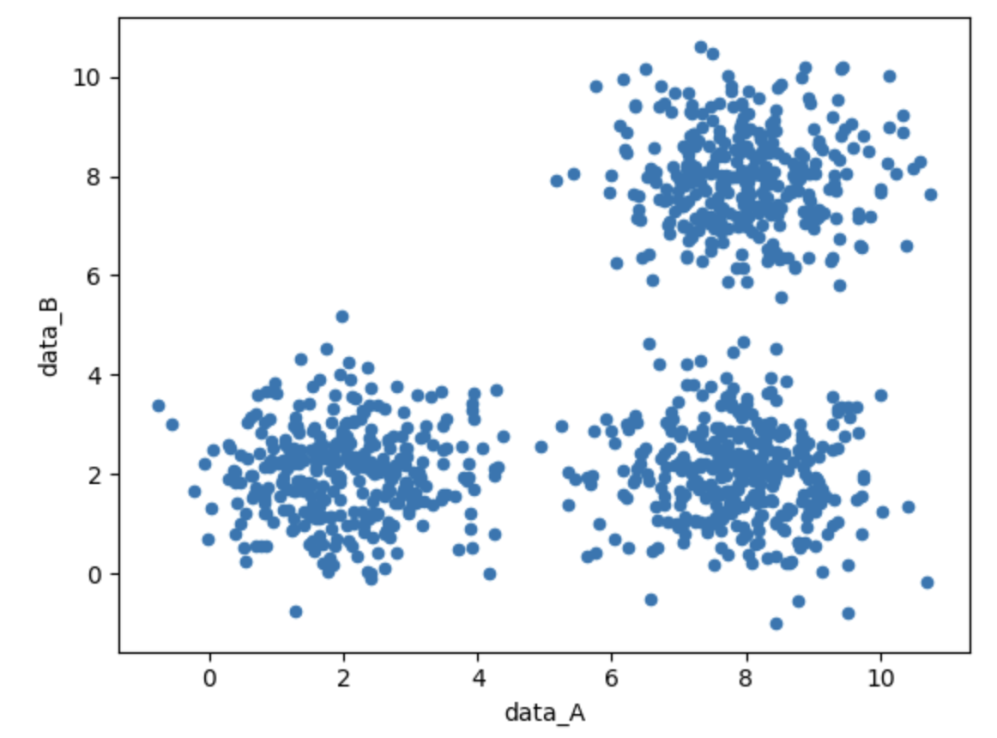

In [24]:
from IPython.display import Image
Image("images/threeclouds.webp")

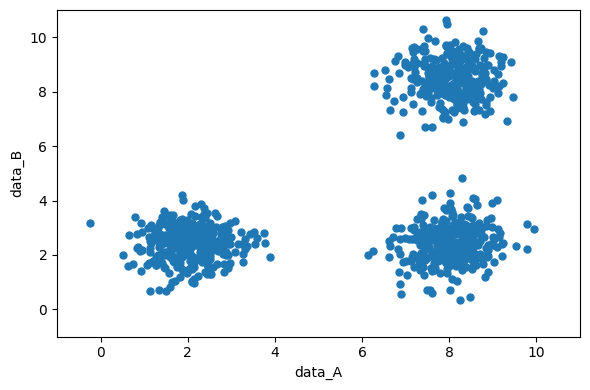

In [ ]:
# Reproducing the Graph
# Reproducible RNG
rng = np.random.default_rng(2026)

# Points per cluster
n = 300

# --- THREE segments for X (data_A) ---
# Left cluster ~2; two right clusters ~8
x_seg1 = rng.normal(loc=2.0, scale=0.6, size=n)   # left
x_seg2 = rng.normal(loc=8.0, scale=0.6, size=n)   # right-bottom
x_seg3 = rng.normal(loc=8.0, scale=0.6, size=n)   # right-top

# --- THREE segments for Y (data_B) ---
# Two lower-band clusters
y_seg1 = rng.normal(loc=2.5, scale=0.7, size=n)   # pairs with x_seg1 → lower-left
y_seg2 = rng.normal(loc=2.5, scale=0.7, size=n)   # pairs with x_seg2 → lower-right
y_seg3 = rng.normal(loc=8.5, scale=0.7, size=n)   # pairs with x_seg3 → upper-right

# Pair segments 1-1, 2-2, 3-3, then JOIN into single series
x = np.concatenate([x_seg1, x_seg2, x_seg3])
y = np.concatenate([y_seg1, y_seg2, y_seg3])

#Cluster labels
labels = (['LL']*n) + (['LR']*n) + (['UR']*n)
df = pd.DataFrame({'data_A': x, 'data_B': y, 'cluster': labels})

# Plot
plt.figure(figsize=(6,4))
plt.scatter(df['data_A'], df['data_B'], s=25)
plt.xlabel('data_A')
plt.ylabel('data_B')
plt.xlim(-1, 11)
plt.ylim(-1, 11)
plt.tight_layout()
plt.savefig('three_clouds.png', dpi=150)
plt.show()

Would you expect to see a correlation for this challenge problem?  (Hint: does knowing the value of data_A tell you anything about the value of data_B - in particular, whether it is large or small?)  If you managed to reproduce the graph using data, test it yourself using the corr() function.

In [32]:
# Testing the correlation of data_A and data_B
df['data_A'].corr(df['data_B'])

np.float64(0.48040277477036425)

### Explanation: Do we expect data_A and data_B to have a Correlation
* data_A and data_B do have a positive correlation - significant, but not too strong
* Knowing the value of data_A will help up understand the value of data_B because knowing the value of data_A can help us determine what cluster data_B would be in. For example,
    * If data_A was a low, we'd expect data_B to also be low, and exist in the lower left cluster.
    * When data_A is high, data_B may be low or it may be high.
    * However, if data_A is high, data_B is more likely to be high than when data_A is low.
* Therefore, there is a positive correlation between data_A and data_B; significant, but not too strong.

Here is a histogram.  Can you provide data that will approximately re-create this histogram?

It is okay if the precise numbers are not re-created; just the general shape: tailing off on either side, but tailing off to a nonzero number.  (In this case, about 300).

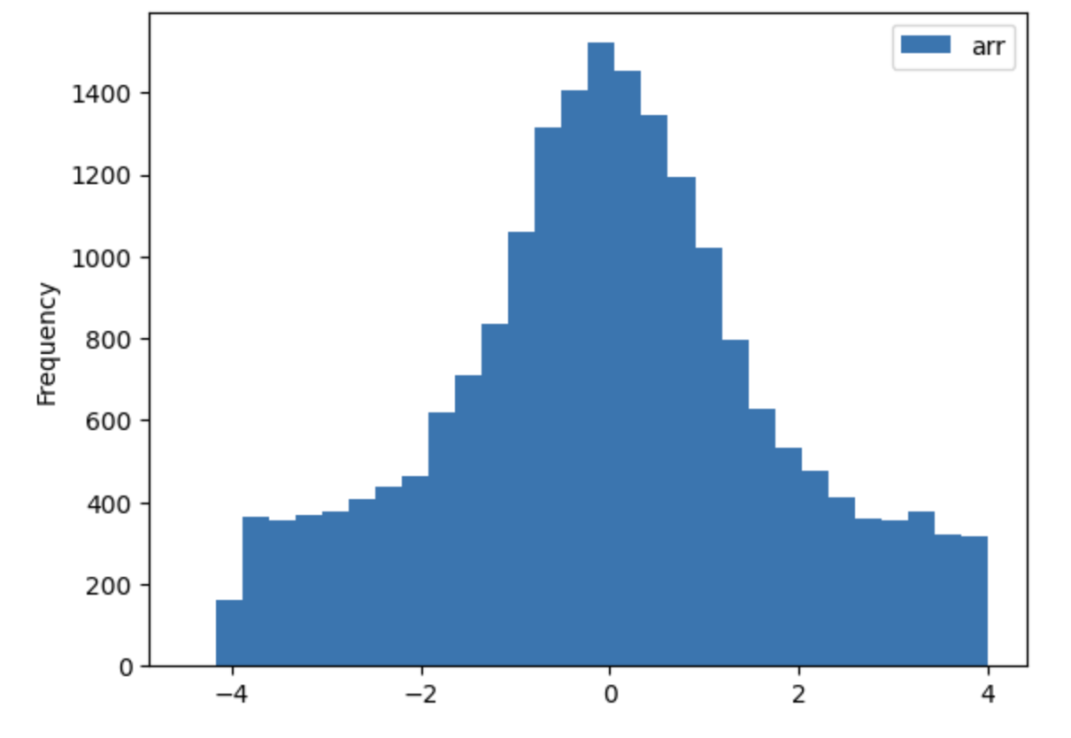

In [25]:
from IPython.display import Image
Image("images/histogram.webp")

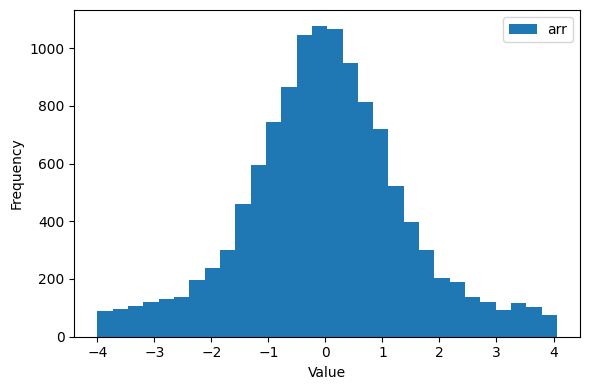

In [ ]:
# Recreating the Graph
rng = np.random.default_rng(7)

# Mixture: a big normal peak + a smaller uniform background to keep tails > 0
n_total = 12000
n_normal = 9000
n_uniform = n_total - n_normal

center = rng.normal(loc=0.0, scale=1.0, size=n_normal)
background = rng.uniform(-4, 4, size=n_uniform)
arr = np.concatenate([center, background])

# Plot with 30 bins to resemble the example
plt.figure(figsize=(6,4))
plt.hist(arr, bins=30, edgecolor='none', label='arr')
plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Create a line plot that shows a sales volume of soft drinks that decreases, then increases over the course of a year, in a U-shaped curve, but with some noise.

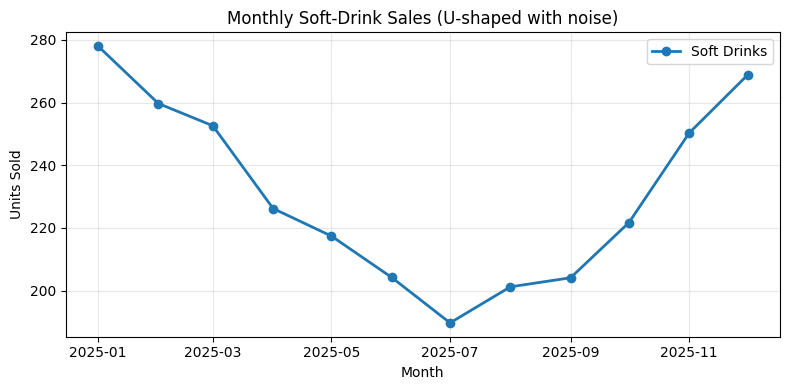

In [ ]:
# Line Plot Showing Volume of Soft Drinks Decreasing then Increasing

# Reproducible random noise
rng = np.random.default_rng(123)

# 12 months
months = pd.date_range('2025-01-01', periods=12, freq='MS')

# Create a U-shaped baseline using a quadratic centered mid-year
# Scale and shift to look like realistic monthly sales volumes
x = np.linspace(-1, 1, 12)
baseline = 200 + 80*(x**2)

# Add seasonal tilt (e.g., slightly higher in Q4) and random noise
seasonal = 10*np.sin(2*np.pi*(np.arange(12)/12 + 0.1))
noise = rng.normal(0, 8, size=12)

sales = baseline + seasonal + noise

# Put into DataFrame
sales_df = pd.DataFrame({
    'month': months,
    'soft_drink_sales': sales.round(1)
})

# Plot
plt.figure(figsize=(8,4))
plt.plot(sales_df['month'], sales_df['soft_drink_sales'], marker='o', linewidth=2, label='Soft Drinks')
plt.title('Monthly Soft-Drink Sales (U-shaped with noise)')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Create an area plot that shows the sales volume for two brands of soft drinks, one of which is increasing then decreasing, the other decreasing then increasing.

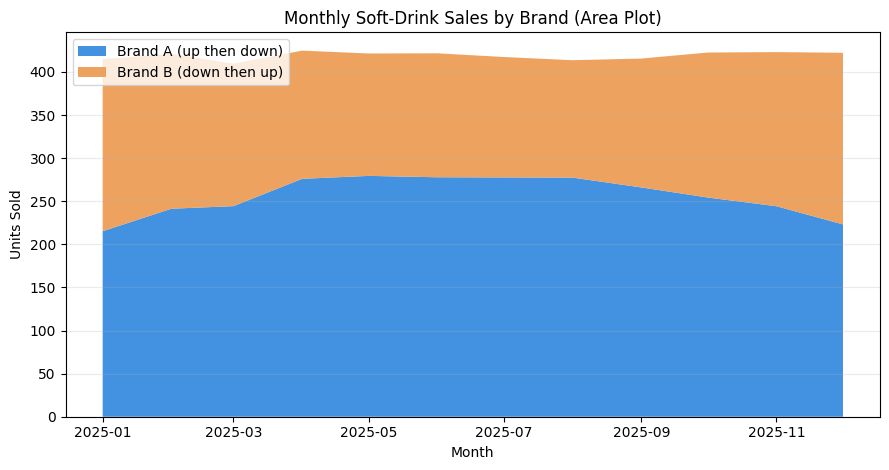

In [ ]:
# Graph Showing Sales Volume of two brands of soft drinks

# Reproducible noise
rng = np.random.default_rng(2026)

# 12 months
months = pd.date_range('2025-01-01', periods=12, freq='MS')

# Create two brands:
# Brand A: increases then decreases (inverted U)
x = np.linspace(-1, 1, 12)
brand_a_base = 220 - 60*(x**2 - 1)
brand_a_noise = rng.normal(0, 6, size=12)
brand_a = (brand_a_base + brand_a_noise).round(1)

# Brand B: decreases then increases (U shape)
brand_b_base = 140 + 60*(x**2)
brand_b_noise = rng.normal(0, 6, size=12)
brand_b = (brand_b_base + brand_b_noise).round(1)

# Ensure no negatives
brand_a = np.clip(brand_a, 0, None)
brand_b = np.clip(brand_b, 0, None)

# Assemble DataFrame
sales_df = pd.DataFrame({
    'Month': months,
    'Brand_A': brand_a,
    'Brand_B': brand_b
})


# --- Area plot (stacked) ---
plt.figure(figsize=(9,4.8))
plt.stackplot(
    sales_df['Month'],
    sales_df['Brand_A'],
    sales_df['Brand_B'],
    labels=['Brand A (up then down)', 'Brand B (down then up)'],
    colors=['#2E86DE', '#EB984E'],
    alpha=0.9
)
plt.title('Monthly Soft-Drink Sales by Brand (Area Plot)')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend(loc='upper left')
plt.grid(True, axis='y', alpha=0.25)
plt.tight_layout()

# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 71-85 of the Storytelling With Data book as best you can.  (The first half of chapter three).

In [1]:
import matplotlib.pyplot as plt

# Create Dummy Data
months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

ticket_received = [160, 180, 235, 145, 180, 160, 130, 200, 160, 135, 145, 175]
ticket_processed = [160, 180, 240, 145, 180, 150, 120, 155, 125, 100, 120, 140]


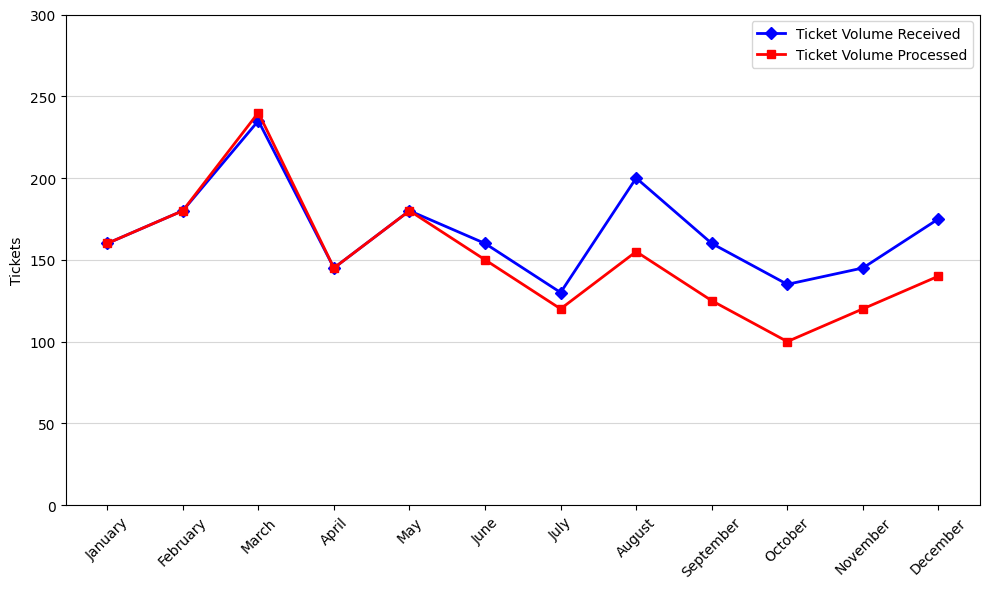

In [2]:
# Create figure
plt.figure(figsize=(10,6))

# Plot lines
plt.plot(months, ticket_received, marker='D', color='blue', linewidth=2,
         label='Ticket Volume Received')
plt.plot(months, ticket_processed, marker='s', color='red', linewidth=2,
         label='Ticket Volume Processed')

# Formatting
plt.ylim(0, 300)
plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.xticks(rotation=45)
plt.ylabel("Tickets")
plt.legend()

# Show plot
plt.tight_layout()
plt.show()